## **Early Clinical Deterioration Risk Prediction**

###Setup & System Configuration

In [1]:
# Setup and Importing Libraries

import os
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

###Drive Mount & Paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/physionet2012")
SET_A_DIR = BASE_DIR / "set-a"
OUTCOMES_PATH = BASE_DIR / "Outcomes-a.txt"

print("SET_A_DIR exists:", SET_A_DIR.exists())
print("OUTCOMES_PATH exists:", OUTCOMES_PATH.exists())

Mounted at /content/drive
SET_A_DIR exists: True
OUTCOMES_PATH exists: True


###Loading Outcomes File

In [3]:
# Load Target File (Outcomes)

outcomes = pd.read_csv(OUTCOMES_PATH)

# Standardize column names
outcomes.columns = outcomes.columns.str.lower().str.replace("-", "_")
outcomes = outcomes.rename(columns={"in_hospital_death": "in_hosp_death"})

print(outcomes.head())
print(outcomes["in_hosp_death"].value_counts())

   recordid  saps_i  sofa  length_of_stay  survival  in_hosp_death
0    132539       6     1               5        -1              0
1    132540      16     8               8        -1              0
2    132541      21    11              19        -1              0
3    132543       7     1               9       575              0
4    132545      17     2               4       918              0
in_hosp_death
0    3446
1     554
Name: count, dtype: int64


### Exploring the Raw Patient Files

In [4]:
# Inspect raw patient files

patient_files = sorted(list(SET_A_DIR.glob("*.txt")))
print("Total patients: ", len(patient_files), "\n\n")

sample_file = patient_files[0]
df_sample = pd.read_csv(sample_file)

df_sample.head(500)

Total patients:  4000 




,Time,Parameter,Value
0,00:00,RecordID,132539.00
1,00:00,Age,54.00
2,00:00,Gender,0.00
3,00:00,Height,-1.00
4,00:00,ICUType,4.00
...,...,...,...
268,47:37,NIMAP,79.33
269,47:37,NISysABP,128.00
270,47:37,RespRate,23.00
271,47:37,Temp,37.80


### Data Cleaning


In [5]:
# Time stamp cleaning

def time_to_hours(t):
    hh, mm = t.split(":")
    return int(hh) + int(mm)/60

def clean_value(v):
    try:
        val = float(v)
    except:
        return np.nan
    return np.nan if val == -1 else val

### Feature Extraction (Time-Series Engineering)

In [6]:
from sklearn.linear_model import LinearRegression

GENERAL_DESCRIPTORS = {"RecordID", "Age", "Gender", "Height", "ICUType", "Weight"}

def extract_features(file_path, window_hours=48):

    df = pd.read_csv(file_path)

    df["hours"] = df["Time"].apply(time_to_hours)
    df["Value"] = df["Value"].apply(clean_value)

    df = df[df["hours"] <= window_hours]

    features = {}
    record_id = int(file_path.stem)
    features["RecordID"] = record_id

    # Static features
    static_rows = df[df["Parameter"].isin(GENERAL_DESCRIPTORS)]
    for _, row in static_rows.iterrows():
        features[f"{row['Parameter']}_static"] = row["Value"]

    ts_df = df[~df["Parameter"].isin({"RecordID"})]

    for var, group in ts_df.groupby("Parameter"):

        group = group.sort_values("hours")
        values = group["Value"].dropna().values
        times = group["hours"].dropna().values

        prefix = f"{var}_ts" if var == "Weight" else var

        if len(values) == 0:
            continue

        features[f"{prefix}_mean"] = np.mean(values)
        features[f"{prefix}_std"] = np.std(values)
        features[f"{prefix}_min"] = np.min(values)
        features[f"{prefix}_max"] = np.max(values)
        features[f"{prefix}_last"] = values[-1]

        if len(values) > 1 and np.ptp(times) > 0:
            model = LinearRegression()
            model.fit(times.reshape(-1,1), values)
            features[f"{prefix}_slope"] = model.coef_[0]
        else:
            features[f"{prefix}_slope"] = 0

    return features

### Building the Dataset

In [11]:
from sklearn.linear_model import LinearRegression

GENERAL_DESCRIPTORS = {"RecordID", "Age", "Gender", "Height", "ICUType", "Weight"}

def time_to_hours(t):
    hh, mm = t.split(":")
    return int(hh) + int(mm)/60

def clean_value(v):
    try:
        val = float(v)
    except:
        return np.nan
    return np.nan if val == -1 else val

def extract_features(file_path, window_hours=48):

    df = pd.read_csv(file_path)

    df["hours"] = df["Time"].apply(time_to_hours)
    df["Value"] = df["Value"].apply(clean_value)

    df = df[df["hours"] <= window_hours]

    features = {}
    record_id = int(file_path.stem)
    features["RecordID"] = record_id

    # Static features
    static_rows = df[df["Parameter"].isin(GENERAL_DESCRIPTORS)]
    for _, row in static_rows.iterrows():
        features[f"{row['Parameter']}_static"] = row["Value"]

    ts_df = df[~df["Parameter"].isin({"RecordID"})]

    for var, group in ts_df.groupby("Parameter"):

        group = group.sort_values("hours")
        # Fix: Ensure 'values' and 'times' have consistent lengths by dropping NaNs together
        filtered_group = group.dropna(subset=["Value", "hours"])
        values = filtered_group["Value"].values
        times = filtered_group["hours"].values

        prefix = f"{var}_ts" if var == "Weight" else var

        if len(values) == 0:
            continue

        features[f"{prefix}_mean"] = np.mean(values)
        features[f"{prefix}_std"] = np.std(values)
        features[f"{prefix}_min"] = np.min(values)
        features[f"{prefix}_max"] = np.max(values)
        features[f"{prefix}_last"] = values[-1]

        if len(values) > 1 and np.ptp(times) > 0:
            model = LinearRegression()
            model.fit(times.reshape(-1,1), values)
            features[f"{prefix}_slope"] = model.coef_[0]
        else:
            features[f"{prefix}_slope"] = 0

    return features

# Building Feature Table(Dataset)

# Number of Patients
N = 4000

rows = []
for fp in tqdm(patient_files[:N]):
    rows.append(extract_features(fp, window_hours=48))

X = pd.DataFrame(rows)
print("Feature matrix shape:", X.shape)

X.head()

100%|██████████| 4000/4000 [04:11<00:00, 15.93it/s]


Feature matrix shape: (4000, 253)


,RecordID,RecordID_static,Age_static,Gender_static,Height_static,ICUType_static,Weight_static,Age_mean,Age_std,Age_min,...,TroponinI_min,TroponinI_max,TroponinI_last,TroponinI_slope,TroponinT_mean,TroponinT_std,TroponinT_min,TroponinT_max,TroponinT_last,TroponinT_slope
0,132539,132539.0,54.0,0.0,NaN,4.0,NaN,54.0,0.0,54.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,132540,132540.0,76.0,1.0,175.3,2.0,81.6,76.0,0.0,76.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,132541,132541.0,44.0,0.0,NaN,3.0,56.7,44.0,0.0,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,132543,132543.0,68.0,1.0,180.3,3.0,84.6,68.0,0.0,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,132545,132545.0,88.0,0.0,NaN,3.0,NaN,88.0,0.0,88.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Weight was treated as both an admission descriptor and a potentially repeated measurement. To avoid naming conflicts, repeated weight observations were stored as time-series-derived features (Weight_ts_*), while the admission value was retained as Weight_static.

In [12]:
print("Total no. of sample patients: ", len(X))

Total no. of sample patients:  4000


### Merge with Target File

In [13]:
# Merge the patient dataset with Outcomes(target)

data = X.merge(outcomes[["recordid", "in_hosp_death"]],
               left_on="RecordID",
               right_on="recordid",
               how="inner")

data = data.drop(columns=["recordid"])

print("Final dataset shape:", data.shape)
print(data["in_hosp_death"].value_counts())

Final dataset shape: (4000, 254)
in_hosp_death
0    3446
1     554
Name: count, dtype: int64


### Exploratory Data Analysis(EDA)

#### Missingness

In [14]:
missing_percent = data.isna().mean().sort_values(ascending=False)
missing_percent.head(10)

,0
TroponinI_last,0.94875
TroponinI_slope,0.94875
TroponinI_min,0.94875
TroponinI_std,0.94875
TroponinI_mean,0.94875
TroponinI_max,0.94875
Cholesterol_mean,0.92375
Cholesterol_min,0.92375
Cholesterol_max,0.92375
Cholesterol_slope,0.92375


Features with extremely high missingness were reviewed separately. Variables with more than 90% missingness, such as TroponinI and Cholesterol-derived summaries, were treated cautiously because their values were unavailable for most ICU stays. In the main pipeline, median imputation was used to preserve feature-space consistency, but the discussion acknowledges that such variables may contribute limited stable information and should be reconsidered in future work using missingness-aware modelling or feature exclusion thresholds.

### Target Distribution

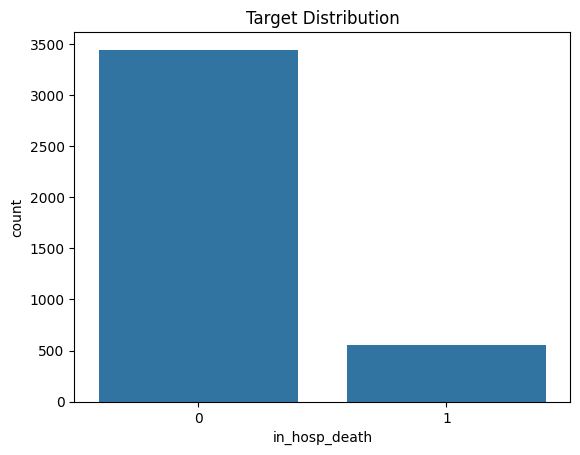

In [16]:
sns.countplot(x="in_hosp_death", data=data)
plt.title("Target Distribution")
plt.savefig("target_distribution.png")
plt.show()

### Feature Distribution

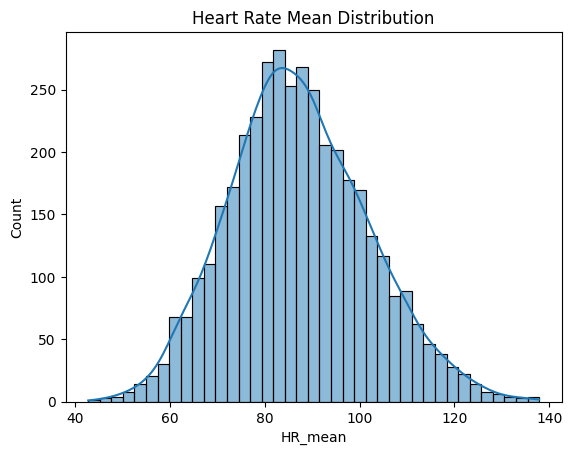

In [18]:
sns.histplot(data["HR_mean"], kde=True)
plt.title("Heart Rate Mean Distribution")
plt.savefig("hr_mean_distribution.png")
plt.show()

### Model Building

In [19]:
# Model Preperation, preprocessing & Train-Test Split

y = data["in_hosp_death"]
X_ml = data.drop(columns=["in_hosp_death", "RecordID","RecordID_static"])

X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [20]:
# Random Forest Model - Baseline

rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf.fit(X_train, y_train)

rf_preds = rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_preds)

print("Random Forest AUC:", rf_auc)

Random Forest AUC: 0.8732854770590619


In [21]:
#X_ml = data.drop(columns=["in_hosp_death", "RecordID", "RecordID_static"])

In [22]:
# Model 2 - XGBoost
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict_proba(X_test)[:,1]

xgb_auc = roc_auc_score(y_test, xgb_preds)

print("XGBoost AUC:", xgb_auc)

XGBoost AUC: 0.8902705317799657


In [23]:
#Model 3 - MLP
from sklearn.neural_network import MLPClassifier

mlp_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation="relu",
        max_iter=300,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

mlp_preds = mlp_model.predict_proba(X_test)[:,1]

mlp_auc = roc_auc_score(y_test, mlp_preds)

print("MLP AUC:", mlp_auc)

MLP AUC: 0.7560572183213693


Why MLP performed poorly?
1. Dataset size is small (few thousand patients)
2. Features are tabular and noisy
3. Neural networks need much more data

In [24]:
# Model Performance Comparision

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "MLP"],
    "AUC": [rf_auc, xgb_auc, mlp_auc]
})

results

,Model,AUC
0,Random Forest,0.873285
1,XGBoost,0.890271
2,MLP,0.756057


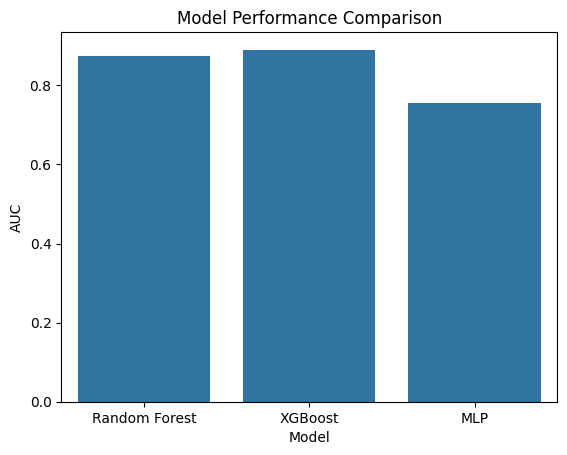

In [26]:
sns.barplot(data=results, x="Model", y="AUC")
plt.title("Model Performance Comparison")
plt.show()

Among the evaluated models, XGBoost achieved the strongest discrimination performance on the held-out test set with a ROC-AUC of 0.890, outperforming Random Forest (0.873) and MLP (0.756). This suggests that gradient-boosted tree ensembles are better suited to the nonlinear and sparsely observed tabular feature space derived from ICU time-series summaries.

## Cross validation

In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb_model,
    X_ml,
    y,
    cv=5,
    scoring="roc_auc"
)

print("CV AUC:", scores.mean())
print("Std:", scores.std())

CV AUC: 0.850067471982156
Std: 0.006935291766845142


Five-fold cross-validation showed stable predictive performance for the XGBoost model, with a mean ROC-AUC of 0.850 and a standard deviation of 0.007. This suggests the model generalises reasonably consistently across folds.

Five-fold cross-validation produced a mean ROC-AUC of 0.850 with a standard deviation of 0.007, suggesting reasonably stable performance across folds.

## Hyperparameter Tuning - XGBoost


In [28]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric="logloss", random_state=42)

param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3,4,5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
search = RandomizedSearchCV(
    xgb,
    param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [30]:
preds = best_xgb.predict_proba(X_test)[:,1]
roc_auc_score(y_test, preds)

np.float64(0.8969913309535951)

Since XGBoost can natively handle missing values, hyperparameter tuning was performed directly on the XGBoost estimator, while median-imputation pipelines were retained for consistent benchmarking across models.

After hyperparameter optimisation, the best XGBoost model achieved a test ROC-AUC of 0.897, indicating strong predictive ability for estimating future in-hospital mortality risk from early ICU measurements.

## ROC Curve Comparison

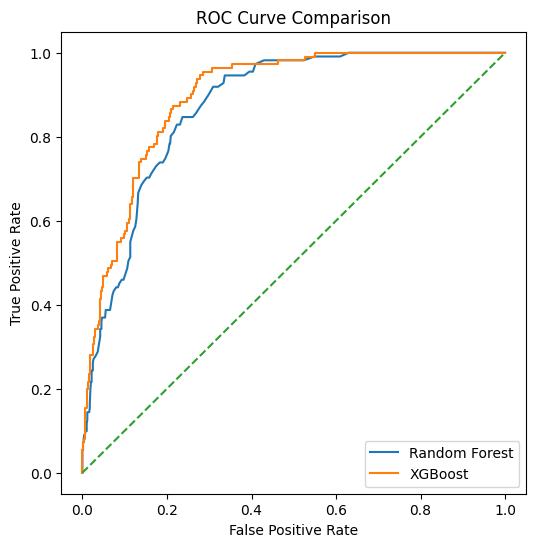

In [31]:
from sklearn.metrics import roc_curve

rf_probs = rf.predict_proba(X_test)[:,1]
xgb_probs = best_xgb.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("roc_curve_comparison.png")
plt.show()

# Interpretability

In [32]:
!pip install shap -q

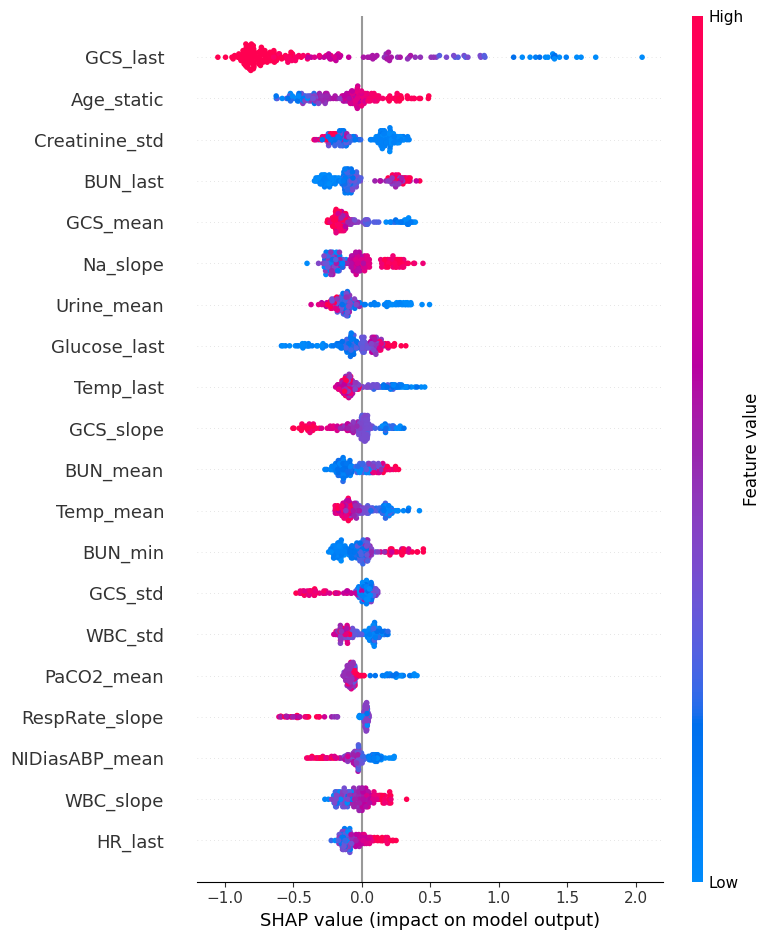

<Figure size 640x480 with 0 Axes>

In [33]:
# SHAP Explainability
import shap
import numpy as np

# Get trained XGBoost model from pipeline
xgb_trained = xgb_model.named_steps["model"]

# Sample safely from test set
sample_size = min(200, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)

# Impute X_sample first because XGBoost in pipeline was trained after imputation
imputer = xgb_model.named_steps["imputer"]
X_sample_imputed = pd.DataFrame(
    imputer.transform(X_sample),
    columns=X_sample.columns,
    index=X_sample.index
)

# SHAP explainer
explainer = shap.TreeExplainer(xgb_trained)
shap_values = explainer.shap_values(X_sample_imputed)

# Summary plot
shap.summary_plot(shap_values, X_sample_imputed)
plt.savefig("shap_summary_plot.png")
plt.show()


In [34]:
rf_model = rf.named_steps["model"]

importances = rf_model.feature_importances_
features = X_ml.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
27,GCS_last,0.039229
23,GCS_mean,0.027063
28,GCS_slope,0.019769
26,GCS_max,0.018407
119,Urine_mean,0.016222
11,BUN_mean,0.015823
15,BUN_last,0.015566
13,BUN_min,0.015266
14,BUN_max,0.014079
120,Urine_std,0.010766


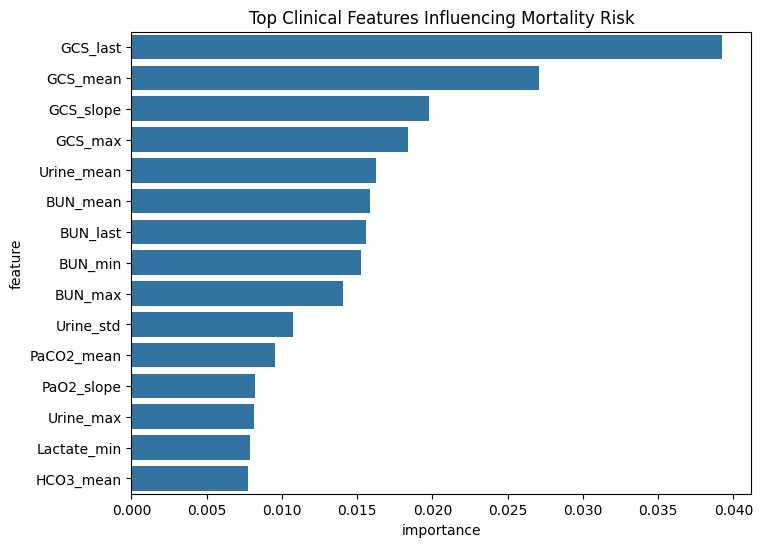

In [36]:
top_features = importance_df.head(15)

plt.figure(figsize=(8,6))
sns.barplot(
    data=top_features,
    y="feature",
    x="importance"
)

plt.title("Top Clinical Features Influencing Mortality Risk")
plt.savefig("top_features_plot.png")
plt.show()

Clinical interpretability

Feature importance analysis highlighted variables related to neurological status and physiological instability, with Glasgow Coma Score-derived features appearing among the strongest predictors, alongside renal and respiratory markers such as BUN, urine output, PaCO2, PaO2 trend, lactate, and bicarbonate. This is clinically plausible, as deterioration risk is often reflected through changes in consciousness, renal function, perfusion, and respiratory status.

In [37]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_ml.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

## Time Window Sensitivity Analysis

In [38]:
def build_window_dataset(patient_files, outcomes, window_hours=48, max_patients=None):
    """
    Build a modelling dataset for a given observation window.
    """
    rows = []

    files_to_use = patient_files if max_patients is None else patient_files[:max_patients]

    for fp in tqdm(files_to_use, desc=f"Building dataset for {window_hours}h"):
        try:
            rows.append(extract_features(fp, window_hours=window_hours))
        except Exception as e:
            print(f"Skipping {fp.name} due to error: {e}")

    X_window = pd.DataFrame(rows)

    data_window = X_window.merge(
        outcomes[["recordid", "in_hosp_death"]],
        left_on="RecordID",
        right_on="recordid",
        how="inner"
    )

    data_window = data_window.drop(columns=["recordid"], errors="ignore")

    return data_window

In [39]:
time_windows = [6, 12, 24, 48]
window_results = []

In [40]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

for window in time_windows:
    # Build dataset for this window
    data_window = build_window_dataset(
        patient_files=patient_files,
        outcomes=outcomes,
        window_hours=window,
        max_patients= 2000
    )

    # Separate target and features
    y_window = data_window["in_hosp_death"]
    X_window = data_window.drop(columns=["in_hosp_death", "RecordID"], errors="ignore")

    # Remove identifier if present accidentally
    if "RecordID_static" in X_window.columns:
        X_window = X_window.drop(columns=["RecordID_static"])

    # Train-test split
    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
        X_window,
        y_window,
        test_size=0.2,
        stratify=y_window,
        random_state=42
    )

    # Handle class imbalance
    scale = (y_train_w == 0).sum() / max((y_train_w == 1).sum(), 1)

    # XGBoost pipeline
    xgb_window_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale,
            eval_metric="logloss",
            random_state=42
        ))
    ])

    # Fit model
    xgb_window_model.fit(X_train_w, y_train_w)

    # Predict probabilities
    preds_w = xgb_window_model.predict_proba(X_test_w)[:, 1]

    # Evaluate
    auc_w = roc_auc_score(y_test_w, preds_w)

    # Save results
    window_results.append({
        "Window (hours)": window,
        "Patients": len(data_window),
        "Features": X_window.shape[1],
        "AUC": auc_w
    })

    print(f"Window {window}h | Patients={len(data_window)} | Features={X_window.shape[1]} | AUC={auc_w:.4f}")

Building dataset for 6h: 100%|██████████| 2000/2000 [01:27<00:00, 22.87it/s]


Window 6h | Patients=2000 | Features=251 | AUC=0.7631


Building dataset for 12h: 100%|██████████| 2000/2000 [01:41<00:00, 19.77it/s]


Window 12h | Patients=2000 | Features=251 | AUC=0.7907


Building dataset for 24h: 100%|██████████| 2000/2000 [02:08<00:00, 15.56it/s]


Window 24h | Patients=2000 | Features=251 | AUC=0.8075


Building dataset for 48h: 100%|██████████| 2000/2000 [01:59<00:00, 16.68it/s]


Window 48h | Patients=2000 | Features=251 | AUC=0.8671


In [41]:
window_results_df = pd.DataFrame(window_results)
window_results_df

,Window (hours),Patients,Features,AUC
0,6,2000,251,0.763132
1,12,2000,251,0.790701
2,24,2000,251,0.807478
3,48,2000,251,0.867117


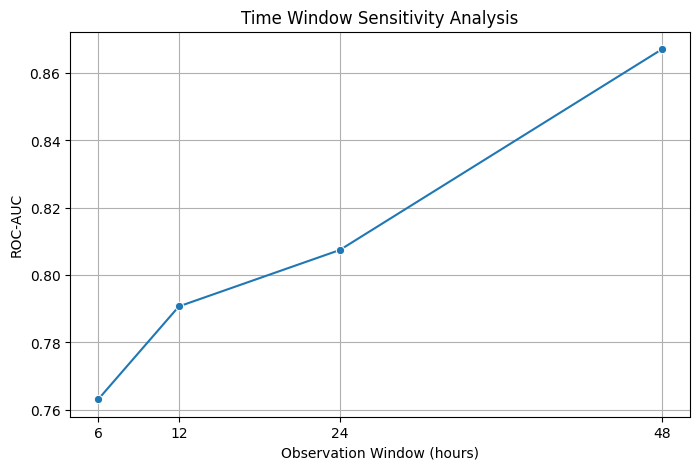

In [42]:
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=window_results_df,
    x="Window (hours)",
    y="AUC",
    marker="o"
)

plt.title("Time Window Sensitivity Analysis")
plt.xlabel("Observation Window (hours)")
plt.ylabel("ROC-AUC")
plt.xticks(time_windows)
plt.grid(True)
plt.savefig("time_window_sensitivity.png")
plt.show()

To evaluate how early clinical deterioration risk can be predicted, a time-window sensitivity analysis was performed. Separate feature sets were generated using the first 6, 12, 24, and 48 hours of ICU data, and model performance was compared using ROC-AUC. This experiment assesses the trade-off between earlier prediction and predictive accuracy.


In [43]:
# Time Window Sensitivity Analysis
#    Random Forest vs XGBoost
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

for window in time_windows:
    # Build dataset
    data_window = build_window_dataset(
        patient_files=patient_files,
        outcomes=outcomes,
        window_hours=window,
        max_patients=500
    )

    # Prepare target/features
    y_window = data_window["in_hosp_death"]
    X_window = data_window.drop(columns=["in_hosp_death", "RecordID"], errors="ignore")

    # Remove accidental identifier if present
    if "RecordID_static" in X_window.columns:
        X_window = X_window.drop(columns=["RecordID_static"])

    # Train/test split
    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
        X_window,
        y_window,
        test_size=0.2,
        stratify=y_window,
        random_state=42
    )

    # Class imbalance ratio for XGBoost
    scale = (y_train_w == 0).sum() / max((y_train_w == 1).sum(), 1)


    # Random Forest

    rf_window_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])

    rf_window_model.fit(X_train_w, y_train_w)
    rf_preds_w = rf_window_model.predict_proba(X_test_w)[:, 1]
    rf_auc_w = roc_auc_score(y_test_w, rf_preds_w)

    # XGBoost

    xgb_window_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale,
            eval_metric="logloss",
            random_state=42
        ))
    ])

    xgb_window_model.fit(X_train_w, y_train_w)
    xgb_preds_w = xgb_window_model.predict_proba(X_test_w)[:, 1]
    xgb_auc_w = roc_auc_score(y_test_w, xgb_preds_w)

    # Save results
    window_results.append({
        "Window (hours)": window,
        "Patients": len(data_window),
        "Features": X_window.shape[1],
        "Random Forest AUC": rf_auc_w,
        "XGBoost AUC": xgb_auc_w
    })

    print(
        f"Window {window}h | Patients={len(data_window)} | Features={X_window.shape[1]} "
        f"| RF AUC={rf_auc_w:.4f} | XGB AUC={xgb_auc_w:.4f}"
    )



Building dataset for 6h: 100%|██████████| 500/500 [00:20<00:00, 24.73it/s]


Window 6h | Patients=500 | Features=251 | RF AUC=0.7193 | XGB AUC=0.7782


Building dataset for 12h: 100%|██████████| 500/500 [00:24<00:00, 20.81it/s]


Window 12h | Patients=500 | Features=251 | RF AUC=0.7284 | XGB AUC=0.7683


Building dataset for 24h: 100%|██████████| 500/500 [00:27<00:00, 18.20it/s]


Window 24h | Patients=500 | Features=251 | RF AUC=0.7579 | XGB AUC=0.7600


Building dataset for 48h: 100%|██████████| 500/500 [00:28<00:00, 17.34it/s]


Window 48h | Patients=500 | Features=251 | RF AUC=0.8326 | XGB AUC=0.8372


In [44]:
window_results_df = pd.DataFrame(window_results)
window_results_df

,Window (hours),Patients,Features,AUC,Random Forest AUC,XGBoost AUC
0,6,2000,251,0.763132,NaN,NaN
1,12,2000,251,0.790701,NaN,NaN
2,24,2000,251,0.807478,NaN,NaN
3,48,2000,251,0.867117,NaN,NaN
4,6,500,251,NaN,0.719269,0.778239
5,12,500,251,NaN,0.728405,0.768272
6,24,500,251,NaN,0.757890,0.759967
7,48,500,251,NaN,0.832641,0.837209


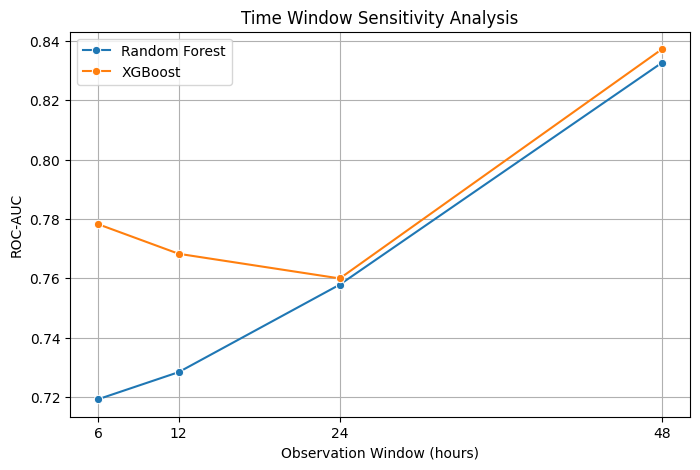

In [45]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=window_results_df,
    x="Window (hours)",
    y="Random Forest AUC",
    marker="o",
    label="Random Forest"
)

sns.lineplot(
    data=window_results_df,
    x="Window (hours)",
    y="XGBoost AUC",
    marker="o",
    label="XGBoost"
)

plt.title("Time Window Sensitivity Analysis")
plt.xlabel("Observation Window (hours)")
plt.ylabel("ROC-AUC")
plt.xticks(time_windows)
plt.grid(True)
plt.legend()
plt.savefig("time_window_sensitivity.png")
plt.show()